# Download các thư viện cần thiết

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tạo hàm để đọc file parquet (đọc các file parquet - data sau khi được processed)

In [2]:
def read_parquet_user(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return user_chunk_df

In [3]:
def read_parquet_item(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    item_chunk_files = [file for file in files if 'item_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return item_chunk_df

In [4]:
def read_parquet_transaction(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    purchase_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    purchase_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_chunk_files]) if purchase_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return purchase_chunk_df

# Tạo hàm lưu file parquet sau mỗi task

In [5]:
def split_and_save_parquet(df, num_files, output_dir):
    """
    Tách DataFrame thành nhiều file Parquet và lưu vào thư mục đích.
    
    :param df: DataFrame cần tách
    :param num_files: Số lượng file Parquet muốn tách
    :param output_dir: Thư mục lưu các file Parquet
    """
    # Đảm bảo thư mục tồn tại
    os.makedirs(output_dir, exist_ok=True)
    
    # Tính số dòng mỗi file sẽ có
    num_rows = df.height
    rows_per_file = num_rows // num_files

    # Tách DataFrame thành các phần và lưu mỗi phần vào một file Parquet
    for i in range(num_files):
        start_row = i * rows_per_file
        # Đảm bảo phần cuối cùng sẽ chứa tất cả các dòng còn lại
        end_row = (i + 1) * rows_per_file if i < num_files - 1 else num_rows
        
        # Tách phần DataFrame
        split_df = df[start_row:end_row]
        
        # Lưu phần DataFrame vào file .parquet
        file_path = os.path.join(output_dir, f"sale_pers.user_chunk_{i}.parquet")
        split_df.write_parquet(file_path)
        print(f"Đã lưu file: {file_path}")

# Load dataset ban đầu

In [6]:
user = read_parquet_user(".././dataset")
user.head()

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
2321395,"""Nữ""",429,"""Hồ Chí Minh""","""Standard""",1557247995,2019-05-07 16:53:15.147,2025-07-07 15:33:10.201316,2,2025-07-16 11:56:29.751170,null,"""Đông Nam Bộ""","""HCM - 2 Đường Số 40""","""In-Store""",1557187200,"""Bình Tân""","""94508bee1b3242a0248c75c9a86681…",false
2321413,"""Nữ""",170,"""Đồng Tháp""","""Standard""",1557248431,2019-05-07 17:00:31.273,2025-07-07 15:33:10.201316,2,2025-07-16 11:56:29.751170,null,"""Đồng bằng sông Cửu Long""","""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",1629244800,"""Sa Đéc""","""9029189445ed6a523d397692174d36…",false
2321355,"""Nữ""",144,"""Khánh Hòa""","""Gold""",1557247196,2019-05-07 16:39:56.703,2025-09-23 08:08:10.457,2,2025-07-16 11:56:29.751170,null,"""Duyên hải Nam Trung Bộ""","""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",1735948800,"""Cam Ranh""","""e5952cc17349bfc6a6c98137e81e82…",false
2321433,"""Nữ""",333,"""Quảng Trị""","""Standard""",1557248908,2019-05-07 17:08:28.650,2025-07-07 15:33:10.201316,2,2025-07-16 11:56:29.751170,null,"""Bắc Trung Bộ""","""QTR - 84 Quốc Lộ 9""","""In-Store""",1557187200,"""Đông Hà""","""c649dcf91aeaae3a46637800c45df0…",false
2321313,"""Nam""",719,"""Lâm Đồng""","""Gold""",1557246359,2019-05-07 16:25:59.400,2025-09-16 19:51:44.287,2,2025-07-16 11:56:29.751170,null,"""Tây Nguyên""","""LDO - Liên Trung""","""In-Store""",1620259200,"""Lâm Hà""","""1f99dc15d160ff015f9807caeaadc6…",false


# Tiền xử lý dữ liệu

1. Tạo bản sao dữ liệu user để tiền xử lý

Làm việc trên bản sao `user_pp` để tránh ghi đè trực tiếp lên dữ liệu gốc `user`.

In [7]:
user_pp = user.clone()
user_pp.head()


customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
2321395,"""Nữ""",429,"""Hồ Chí Minh""","""Standard""",1557247995,2019-05-07 16:53:15.147,2025-07-07 15:33:10.201316,2,2025-07-16 11:56:29.751170,null,"""Đông Nam Bộ""","""HCM - 2 Đường Số 40""","""In-Store""",1557187200,"""Bình Tân""","""94508bee1b3242a0248c75c9a86681…",false
2321413,"""Nữ""",170,"""Đồng Tháp""","""Standard""",1557248431,2019-05-07 17:00:31.273,2025-07-07 15:33:10.201316,2,2025-07-16 11:56:29.751170,null,"""Đồng bằng sông Cửu Long""","""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",1629244800,"""Sa Đéc""","""9029189445ed6a523d397692174d36…",false
2321355,"""Nữ""",144,"""Khánh Hòa""","""Gold""",1557247196,2019-05-07 16:39:56.703,2025-09-23 08:08:10.457,2,2025-07-16 11:56:29.751170,null,"""Duyên hải Nam Trung Bộ""","""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",1735948800,"""Cam Ranh""","""e5952cc17349bfc6a6c98137e81e82…",false
2321433,"""Nữ""",333,"""Quảng Trị""","""Standard""",1557248908,2019-05-07 17:08:28.650,2025-07-07 15:33:10.201316,2,2025-07-16 11:56:29.751170,null,"""Bắc Trung Bộ""","""QTR - 84 Quốc Lộ 9""","""In-Store""",1557187200,"""Đông Hà""","""c649dcf91aeaae3a46637800c45df0…",false
2321313,"""Nam""",719,"""Lâm Đồng""","""Gold""",1557246359,2019-05-07 16:25:59.400,2025-09-16 19:51:44.287,2,2025-07-16 11:56:29.751170,null,"""Tây Nguyên""","""LDO - Liên Trung""","""In-Store""",1620259200,"""Lâm Hà""","""1f99dc15d160ff015f9807caeaadc6…",false


2. Loại bỏ các cột không hữu ích cho mô hình

- `sync_status_id`: cột kỹ thuật, không phản ánh đặc trưng người dùng.  
- `sync_error_message`: 100% giá trị `NULL`.  
- `user_id`: khoá định danh duy nhất, không nên dùng làm feature.  
- `is_deleted`: 100% `False`, không có độ biến thiên.


In [8]:
cols_drop_tech = [
    "sync_status_id",
    "sync_error_message",
    "user_id",
    "is_deleted",
]

user_pp = user_pp.drop([c for c in cols_drop_tech if c in user_pp.columns])
user_pp.head()

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,last_sync_date,region,location_name,install_app,install_date,district
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],datetime[μs],str,str,str,i64,str
2321395,"""Nữ""",429,"""Hồ Chí Minh""","""Standard""",1557247995,2019-05-07 16:53:15.147,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""Đông Nam Bộ""","""HCM - 2 Đường Số 40""","""In-Store""",1557187200,"""Bình Tân"""
2321413,"""Nữ""",170,"""Đồng Tháp""","""Standard""",1557248431,2019-05-07 17:00:31.273,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""Đồng bằng sông Cửu Long""","""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",1629244800,"""Sa Đéc"""
2321355,"""Nữ""",144,"""Khánh Hòa""","""Gold""",1557247196,2019-05-07 16:39:56.703,2025-09-23 08:08:10.457,2025-07-16 11:56:29.751170,"""Duyên hải Nam Trung Bộ""","""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",1735948800,"""Cam Ranh"""
2321433,"""Nữ""",333,"""Quảng Trị""","""Standard""",1557248908,2019-05-07 17:08:28.650,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""Bắc Trung Bộ""","""QTR - 84 Quốc Lộ 9""","""In-Store""",1557187200,"""Đông Hà"""
2321313,"""Nam""",719,"""Lâm Đồng""","""Gold""",1557246359,2019-05-07 16:25:59.400,2025-09-16 19:51:44.287,2025-07-16 11:56:29.751170,"""Tây Nguyên""","""LDO - Liên Trung""","""In-Store""",1620259200,"""Lâm Hà"""


3. Rút gọn nhóm biến địa lý

Giữ lại:
- `region` (ID địa điểm, dạng i32)

Loại bỏ:
- `location_name`
- `location`
- `province`
- `district`

Lý do: các cột này có tương quan rất cao với `location` và chủ yếu là các phân cấp địa lý suy ra từ `location`, không thêm thông tin mới cho mô hình.


In [9]:
cols_drop_geo = [
    "location"
    "location_name",
    "region",
    "district",
]

user_pp = user_pp.drop([c for c in cols_drop_geo if c in user_pp.columns])
user_pp.head()

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,last_sync_date,location_name,install_app,install_date
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],datetime[μs],str,str,i64
2321395,"""Nữ""",429,"""Hồ Chí Minh""","""Standard""",1557247995,2019-05-07 16:53:15.147,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""HCM - 2 Đường Số 40""","""In-Store""",1557187200
2321413,"""Nữ""",170,"""Đồng Tháp""","""Standard""",1557248431,2019-05-07 17:00:31.273,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",1629244800
2321355,"""Nữ""",144,"""Khánh Hòa""","""Gold""",1557247196,2019-05-07 16:39:56.703,2025-09-23 08:08:10.457,2025-07-16 11:56:29.751170,"""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",1735948800
2321433,"""Nữ""",333,"""Quảng Trị""","""Standard""",1557248908,2019-05-07 17:08:28.650,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""QTR - 84 Quốc Lộ 9""","""In-Store""",1557187200
2321313,"""Nam""",719,"""Lâm Đồng""","""Gold""",1557246359,2019-05-07 16:25:59.400,2025-09-16 19:51:44.287,2025-07-16 11:56:29.751170,"""LDO - Liên Trung""","""In-Store""",1620259200


4. Chuẩn hoá biến `gender`

- Lọc bỏ các dòng có gender = "khác" (và chuẩn hoá gender)

In [10]:
user_pp = (
    user_pp
    .filter(
        ~(
            user_pp["gender"]
            .cast(pl.Utf8)
            .str.to_lowercase()
            .str.strip_chars()
            .eq("khác")
        )
    )
)

# 2.2. Chuẩn hoá lại gender còn lại (Nam/Nam/Male/Female/...)
import re

def normalize_gender(x: str) -> str:
    if x is None:
        return None
    x = x.strip().lower()
    if x in ("nam", "male"):
        return "male"
    if x in ("nu", "nữ", "female"):
        return "female"
    # các giá trị lạ còn lại (nếu có) cho vào "other"
    return "other"

user_pp = user_pp.with_columns(
    pl.col("gender")
    .cast(pl.Utf8)
    .map_elements(normalize_gender, return_dtype=pl.Utf8)
    .alias("gender")
)


In [11]:
user_pp

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,last_sync_date,location_name,install_app,install_date
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],datetime[μs],str,str,i64
2321395,"""female""",429,"""Hồ Chí Minh""","""Standard""",1557247995,2019-05-07 16:53:15.147,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""HCM - 2 Đường Số 40""","""In-Store""",1557187200
2321413,"""female""",170,"""Đồng Tháp""","""Standard""",1557248431,2019-05-07 17:00:31.273,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",1629244800
2321355,"""female""",144,"""Khánh Hòa""","""Gold""",1557247196,2019-05-07 16:39:56.703,2025-09-23 08:08:10.457,2025-07-16 11:56:29.751170,"""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",1735948800
2321433,"""female""",333,"""Quảng Trị""","""Standard""",1557248908,2019-05-07 17:08:28.650,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""QTR - 84 Quốc Lộ 9""","""In-Store""",1557187200
2321313,"""male""",719,"""Lâm Đồng""","""Gold""",1557246359,2019-05-07 16:25:59.400,2025-09-16 19:51:44.287,2025-07-16 11:56:29.751170,"""LDO - Liên Trung""","""In-Store""",1620259200
…,…,…,…,…,…,…,…,…,…,…,…
2321363,"""female""",227,"""Bình Dương""","""Standard""",1557247296,2019-05-07 16:41:36.687,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""BDU - 26 Đường DT 746""","""In-Store""",1624838400
2321373,"""female""",649,"""Đồng Nai""","""Standard""",1557247498,2019-05-07 16:44:58.150,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""DON - 4/4 Quốc lộ 20""","""In-Store""",1557187200
2321385,"""female""",207,"""Hồ Chí Minh""","""Standard""",1557247791,2019-05-07 16:49:51.237,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""HCM - 333-335 Đường Số 7""","""In-Store""",1557187200


5. Chuẩn hoá trường `install_app`

- Giữ các nguồn chính: `"In-Store"`, `"SPE"`, `"iOS"`, `"Android"`.  
- Gộp tất cả các nguồn hiếm còn lại vào `"Other App Source"` để giảm số lượng category và tránh nhiễu.


In [12]:
main_install_sources = {"In-Store", "SPE", "iOS", "Android"}

def normalize_install_app(x: str) -> str:
    if x is None:
        return None
    x = x.strip()
    if x in main_install_sources:
        return x
    return "Others"

user_pp = user_pp.with_columns(
    pl.col("install_app")
    .cast(pl.Utf8)
    .map_elements(normalize_install_app, return_dtype=pl.Utf8)
    .alias("install_app")
)

user_pp


customer_id,gender,location,province,membership,timestamp,created_date,updated_date,last_sync_date,location_name,install_app,install_date
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],datetime[μs],str,str,i64
2321395,"""female""",429,"""Hồ Chí Minh""","""Standard""",1557247995,2019-05-07 16:53:15.147,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""HCM - 2 Đường Số 40""","""In-Store""",1557187200
2321413,"""female""",170,"""Đồng Tháp""","""Standard""",1557248431,2019-05-07 17:00:31.273,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",1629244800
2321355,"""female""",144,"""Khánh Hòa""","""Gold""",1557247196,2019-05-07 16:39:56.703,2025-09-23 08:08:10.457,2025-07-16 11:56:29.751170,"""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",1735948800
2321433,"""female""",333,"""Quảng Trị""","""Standard""",1557248908,2019-05-07 17:08:28.650,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""QTR - 84 Quốc Lộ 9""","""In-Store""",1557187200
2321313,"""male""",719,"""Lâm Đồng""","""Gold""",1557246359,2019-05-07 16:25:59.400,2025-09-16 19:51:44.287,2025-07-16 11:56:29.751170,"""LDO - Liên Trung""","""In-Store""",1620259200
…,…,…,…,…,…,…,…,…,…,…,…
2321363,"""female""",227,"""Bình Dương""","""Standard""",1557247296,2019-05-07 16:41:36.687,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""BDU - 26 Đường DT 746""","""In-Store""",1624838400
2321373,"""female""",649,"""Đồng Nai""","""Standard""",1557247498,2019-05-07 16:44:58.150,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""DON - 4/4 Quốc lộ 20""","""In-Store""",1557187200
2321385,"""female""",207,"""Hồ Chí Minh""","""Standard""",1557247791,2019-05-07 16:49:51.237,2025-07-07 15:33:10.201316,2025-07-16 11:56:29.751170,"""HCM - 333-335 Đường Số 7""","""In-Store""",1557187200


## Xử lý các cột thời gian

hiện có các cột:

- timestamp – ingestion time → bỏ

- created_date – ngày tạo user → dùng để tính tuổi user

- updated_date – lần cập nhật hồ sơ cuối → bỏ

- last_sync_date – lần sync gần nhất → dùng để tính days_since_last_sync

- install_date – int64 (epoch seconds) → convert sang datetime rồi tính days_since_install

In [13]:
# Lấy ngày tham chiếu là ngày tạo user mới nhất
ref_date = (
    user_pp
    .select(pl.col("created_date").max().alias("ref_date"))
    ["ref_date"][0]
)
ref_date

datetime.datetime(2025, 9, 30, 22, 0, 36, 623000)

In [14]:
# Convert install_date → datetime
user_pp = user_pp.with_columns(
    pl.from_epoch(pl.col("install_date"), time_unit="s").alias("install_datetime")
)


In [15]:
user_pp = user_pp.with_columns(
    # tuổi user tính theo ngày
    (
        (ref_date - pl.col("created_date")).dt.cast_time_unit("us") 
        / pl.duration(days=1)
    ).alias("user_age_days"),

    # số ngày kể từ khi cài đặt
    (
        (ref_date - pl.col("install_datetime")).dt.cast_time_unit("us") 
        / pl.duration(days=1)
    ).alias("days_since_install"),

    # số ngày kể từ lần sync gần nhất
    (
        (ref_date - pl.col("last_sync_date")).dt.cast_time_unit("us") 
        / pl.duration(days=1)
    ).alias("days_since_last_sync"),
)

In [16]:
cols_drop_time = [
    "timestamp",
    "updated_date",
    # nếu bạn muốn bỏ luôn raw install_date, dùng dòng dưới:
    "install_date",
]

user_pp = user_pp.drop([c for c in cols_drop_time if c in user_pp.columns])

In [17]:
user_pp.head()

customer_id,gender,location,province,membership,created_date,last_sync_date,location_name,install_app,install_datetime,user_age_days,days_since_install,days_since_last_sync
i32,str,i32,str,str,datetime[μs],datetime[μs],str,str,datetime[μs],f64,f64,f64
2321395,"""female""",429,"""Hồ Chí Minh""","""Standard""",2019-05-07 16:53:15.147,2025-07-16 11:56:29.751170,"""HCM - 2 Đường Số 40""","""In-Store""",2019-05-07 00:00:00,2338.213443,2338.917091,76.419524
2321413,"""female""",170,"""Đồng Tháp""","""Standard""",2019-05-07 17:00:31.273,2025-07-16 11:56:29.751170,"""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",2021-08-18 00:00:00,2338.208395,1504.917091,76.419524
2321355,"""female""",144,"""Khánh Hòa""","""Gold""",2019-05-07 16:39:56.703,2025-07-16 11:56:29.751170,"""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",2025-01-04 00:00:00,2338.222684,269.917091,76.419524
2321433,"""female""",333,"""Quảng Trị""","""Standard""",2019-05-07 17:08:28.650,2025-07-16 11:56:29.751170,"""QTR - 84 Quốc Lộ 9""","""In-Store""",2019-05-07 00:00:00,2338.20287,2338.917091,76.419524
2321313,"""male""",719,"""Lâm Đồng""","""Gold""",2019-05-07 16:25:59.400,2025-07-16 11:56:29.751170,"""LDO - Liên Trung""","""In-Store""",2021-05-06 00:00:00,2338.232375,1608.917091,76.419524


Ý nghĩa các feature thời gian

- **user_age_days**: số ngày kể từ khi người dùng được tạo tài khoản → phản ánh vòng đời người dùng.
- **days_since_install**: số ngày kể từ khi người dùng cài ứng dụng → phản ánh mức độ gắn bó kể từ lúc bắt đầu.
- **days_since_last_sync**: số ngày kể từ lần đồng bộ gần nhất → proxy mức độ hoạt động (active/inactive) của người dùng.

Bỏ đi giá trị `giờ`, `phút`, `giây` trong các cột thời gian, chỉ giữ lại `ngày`, `tháng`, `năm` để tính toán sự khác biệt ngày tháng.

In [18]:
user_pp = user_pp.with_columns([
    pl.col("install_datetime").dt.date().alias("install_datetime"),
    pl.col("last_sync_date").dt.date().alias("last_sync_date"),
    pl.col("created_date").dt.date().alias("created_date"),
])

In [19]:
user_pp.head()

customer_id,gender,location,province,membership,created_date,last_sync_date,location_name,install_app,install_datetime,user_age_days,days_since_install,days_since_last_sync
i32,str,i32,str,str,date,date,str,str,date,f64,f64,f64
2321395,"""female""",429,"""Hồ Chí Minh""","""Standard""",2019-05-07,2025-07-16,"""HCM - 2 Đường Số 40""","""In-Store""",2019-05-07,2338.213443,2338.917091,76.419524
2321413,"""female""",170,"""Đồng Tháp""","""Standard""",2019-05-07,2025-07-16,"""ĐTH - 281-283 Nguyễn Sinh Sắc""","""In-Store""",2021-08-18,2338.208395,1504.917091,76.419524
2321355,"""female""",144,"""Khánh Hòa""","""Gold""",2019-05-07,2025-07-16,"""KHO - 2193 -2195 - 2197 Đại Lộ…","""In-Store""",2025-01-04,2338.222684,269.917091,76.419524
2321433,"""female""",333,"""Quảng Trị""","""Standard""",2019-05-07,2025-07-16,"""QTR - 84 Quốc Lộ 9""","""In-Store""",2019-05-07,2338.20287,2338.917091,76.419524
2321313,"""male""",719,"""Lâm Đồng""","""Gold""",2019-05-07,2025-07-16,"""LDO - Liên Trung""","""In-Store""",2021-05-06,2338.232375,1608.917091,76.419524


In [20]:
import polars as pl

# pattern prefix cần bỏ, (?i) = ignore case
prefix_pattern = r"(?i)^(tinh|tỉnh|thanh pho|thành phố|tp\.?|tp)\s+"

user = (
    user
    .with_columns(
        pl.col("province")
        .cast(pl.Utf8)
        .str.strip_chars()                     # bỏ space đầu/cuối
        .str.replace(prefix_pattern, "")       # bỏ tiền tố: Tỉnh..., Thành Phố..., TP...
        .str.strip_chars()                     # làm sạch lại lần nữa
        .alias("province")
    )
)


In [21]:
user.select("province").unique().sort("province")


province
str
"""An Giang"""
"""Bà Rịa - Vũng Tàu"""
"""Bình Dương"""
"""Bình Phước"""
"""Bình Thuận"""
…
"""Đà Nẵng"""
"""Đắk Lắk"""
"""Đắk Nông"""


In [22]:
province_freq = (
    user
    .group_by("province")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)

province_freq.head(20)


province,count
str,u32
"""Hồ Chí Minh""",1224319
"""Đồng Nai""",312380
"""Bình Dương""",287857
"""Hà Nội""",202879
"""Đà Nẵng""",146700
…,…
"""Bình Thuận""",82094
"""Đồng Tháp""",74865
"""Bình Phước""",71215


Lưu data đã được xử lý xuống folder processed_data.

In [23]:
split_and_save_parquet(user_pp, num_files=10, output_dir="./preprocessed-data")

Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_0.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_1.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_2.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_3.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_4.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_5.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_6.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_7.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_8.parquet
Đã lưu file: ./preprocessed-data/sale_pers.user_chunk_9.parquet


# Kiểm chứng dữ liệu sau bước tiền xử lý

In [29]:
import polars as pl

def describe_categorical(df: pl.DataFrame, col: str):
    """
    Trả về frequency table cho 1 cột categorical.
    Gồm:
    - value
    - count
    - pct (tỷ lệ %)
    """
    counts = (
        df
        .group_by(col)
        .agg(pl.count().alias("count"))
        .with_columns(
            (pl.col("count") / pl.col("count").sum()).alias("pct")
        )
        .sort("count", descending=True)
    )
    return counts


In [30]:
categorical_cols = [
    "gender",
    "install_app",
    "province",
]

results = {}

for col in categorical_cols:
    results[col] = describe_categorical(user_pp, col)

/tmp/ipykernel_1389816/1072091738.py:14: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


In [31]:
from matplotlib import cm


def plot_bar_colorful(df_pl, col, top_k=None, save_path=None):
    df = df_pl.to_pandas()

    if top_k is not None:
        df = df.head(top_k)

    if "pct" in df.columns:
        df = df.sort_values("pct", ascending=False)

    n = len(df)
    colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))

    figsize = (12, 5) if col in ("gender", "membership", "install_app") else (30, 5)

    plt.figure(figsize=figsize)
    plt.bar(df[col].astype(str), df["pct"], color=colors)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

/tmp/ipykernel_1389816/1076344465.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


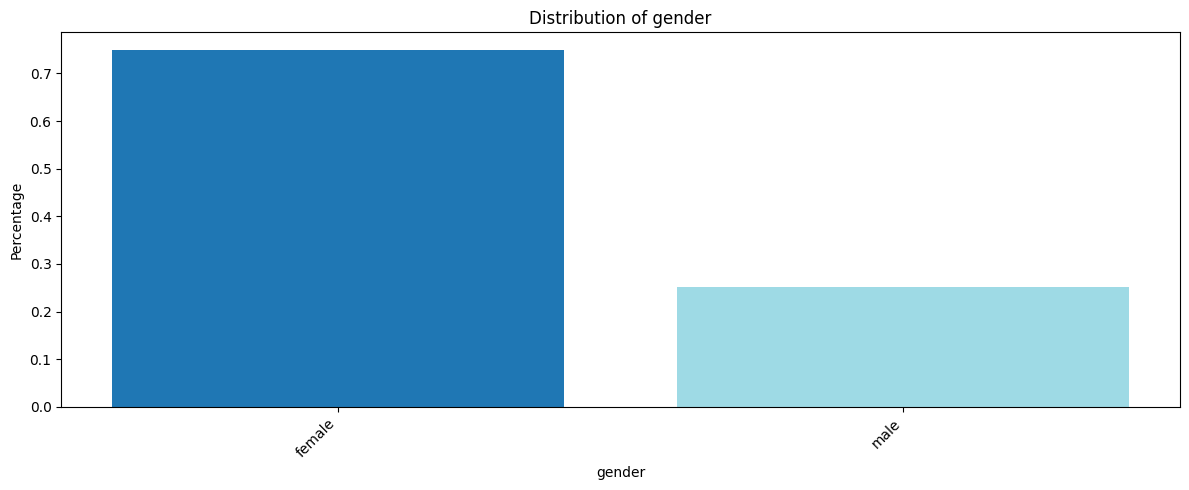

/tmp/ipykernel_1389816/1076344465.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


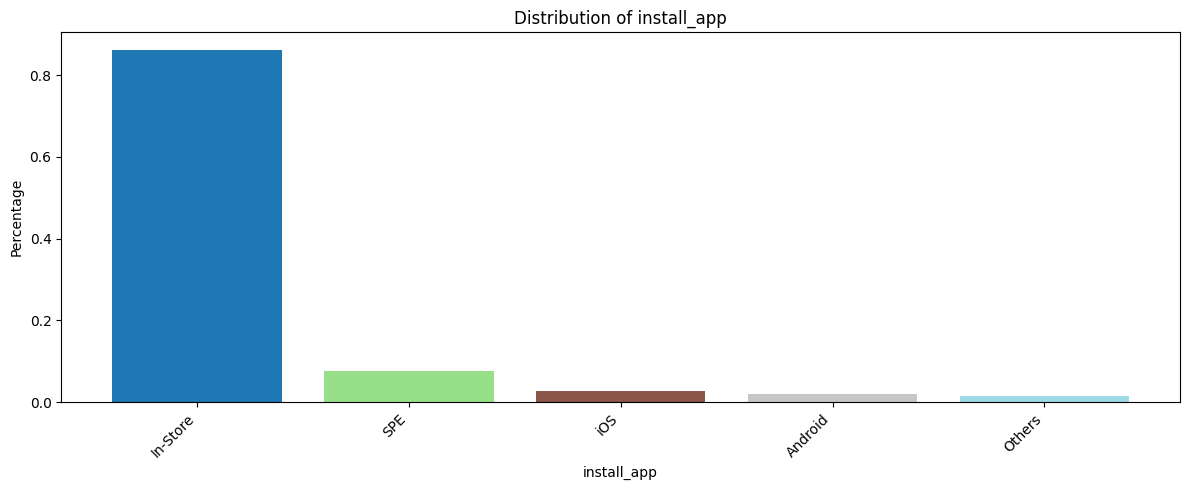

/tmp/ipykernel_1389816/1076344465.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


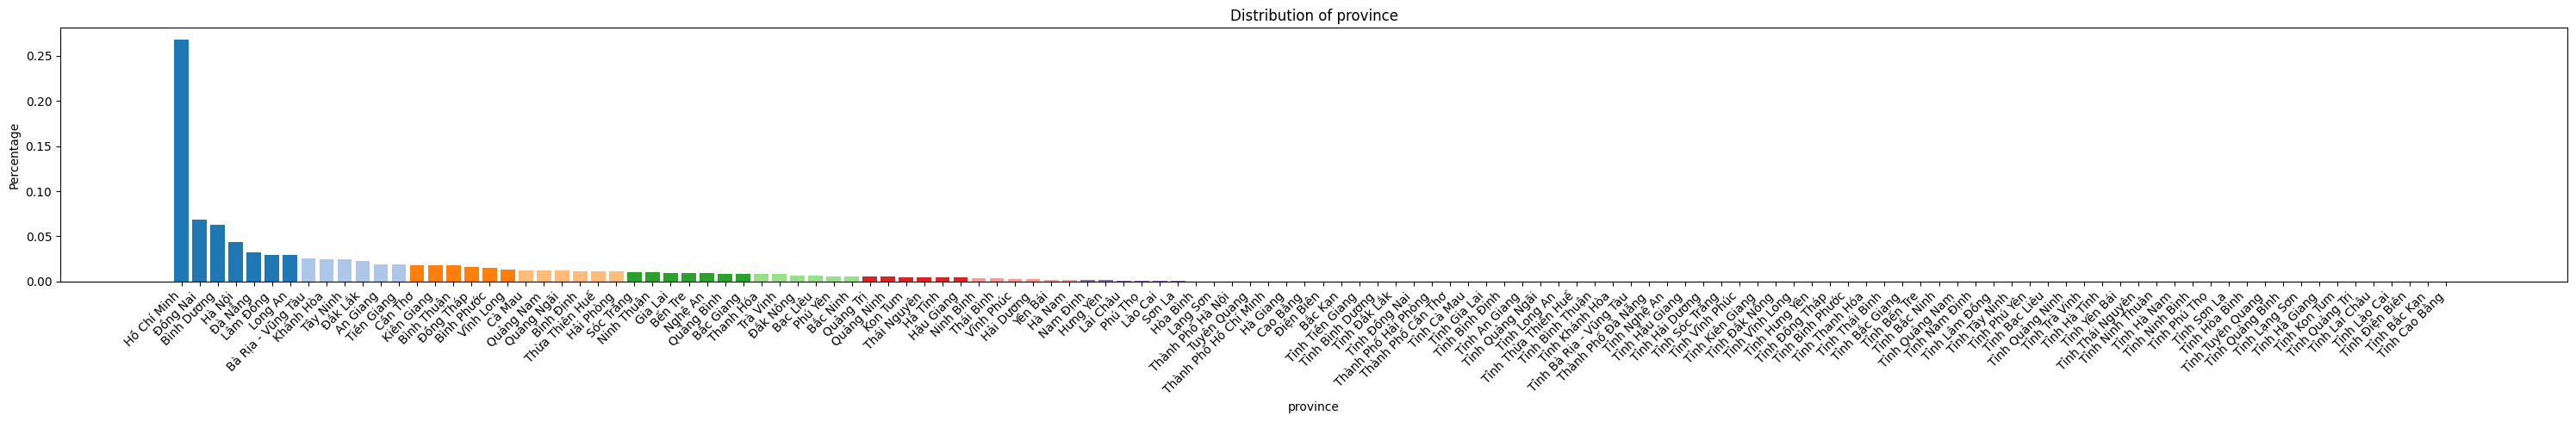

In [32]:
bar_cols = ["gender", "install_app", "province"]

for col in bar_cols:
    plot_bar_colorful(results[col], col)